# CreditNirvana PS1: Comprehensive Exploratory Data Analysis & Visual Encyclopedia
## Deep-Dive Statistical Profiling across 10 Datasets (50 Analytical Visualizations)

**Scope:** Real-Time Fake Promise-to-Pay (PTP) Detection & Typology Classification  
**Datasets:** 10 core CSV files located in `./data/`  
**Contents:** 50 distinct charts, behavioral distribution graphs, agent fraud audits, speech timing metrics, and payment realization curves. Each analysis is self-contained in its own cell.


In [1]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Matplotlib Global Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

DATA_DIR = Path('data')

# 1. Load All Datasets
accounts = pd.read_csv(DATA_DIR / 'accounts.csv')
lenders = pd.read_csv(DATA_DIR / 'lenders.csv')
agents = pd.read_csv(DATA_DIR / 'agents.csv')
splits = pd.read_csv(DATA_DIR / 'splits.csv')
dial_attempts = pd.read_csv(DATA_DIR / 'dial_attempts.csv')
transcripts = pd.read_csv(DATA_DIR / 'call_transcripts.csv')
ptps = pd.read_csv(DATA_DIR / 'ptps.csv')
post_call = pd.read_csv(DATA_DIR / 'post_call_events.csv')
payments = pd.read_csv(DATA_DIR / 'payments.csv')
annotated = pd.read_csv(DATA_DIR / 'annotated_ptp_sample.csv')

# 2. Derive FIFO Attribution Target for Analysis
ptps['captured_ts'] = pd.to_datetime(ptps['captured_ts'])
ptps['promised_date'] = pd.to_datetime(ptps['promised_date'])
payments['payment_ts'] = pd.to_datetime(payments['payment_ts'])
ptps['window_end'] = ptps['promised_date'] + pd.Timedelta(days=3) - pd.Timedelta(seconds=1)

pay_by_acc = {a: g.sort_values('payment_ts') for a, g in payments.groupby('account_id')}
idx_by_acc = ptps.sort_values(['account_id', 'promised_date', 'captured_ts']).groupby('account_id').groups

paid_dict = {}
for acc_id, idxs in idx_by_acc.items():
    g = pay_by_acc.get(acc_id)
    if g is None:
        continue
    rem = {i: ptps.at[i, 'promised_amount'] for i in idxs}
    for i in idxs:
        paid_dict[i] = 0.0
    for r in g.itertuples():
        amt = r.amount
        for i in idxs:
            if ptps.at[i, 'captured_ts'] <= r.payment_ts <= ptps.at[i, 'window_end'] and rem[i] > 0:
                take = min(amt, rem[i])
                paid_dict[i] += take
                rem[i] -= take
                amt -= take
                if amt <= 0:
                    break

ptps['paid_in_window'] = pd.Series(paid_dict).reindex(ptps.index).fillna(0.0)
ptps['target_kept'] = (ptps['paid_in_window'] >= 0.90 * ptps['promised_amount']).astype(int)
ptps['lead_days'] = (ptps['promised_date'].dt.normalize() - ptps['captured_ts'].dt.normalize()).dt.days

print("All 10 datasets loaded and target labels attributed successfully.")


All 10 datasets loaded and target labels attributed successfully.



### Chart 1: Distribution of Borrower Accounts by Lending Portfolio


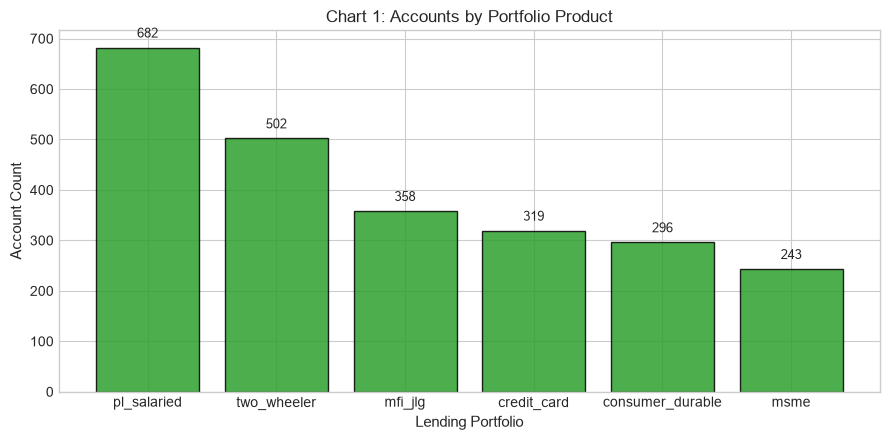

In [2]:
counts = accounts['portfolio'].value_counts()
plt.figure(figsize=(9, 4.5))
bars = plt.bar(counts.index, counts.values, color='#2ca02c', alpha=0.85, edgecolor='black')
plt.title("Chart 1: Accounts by Portfolio Product")
plt.xlabel("Lending Portfolio")
plt.ylabel("Account Count")
for b in bars:
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 20, f"{int(b.get_height()):,d}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()


### Chart 2: Delinquency DPD Bucket Breakdown


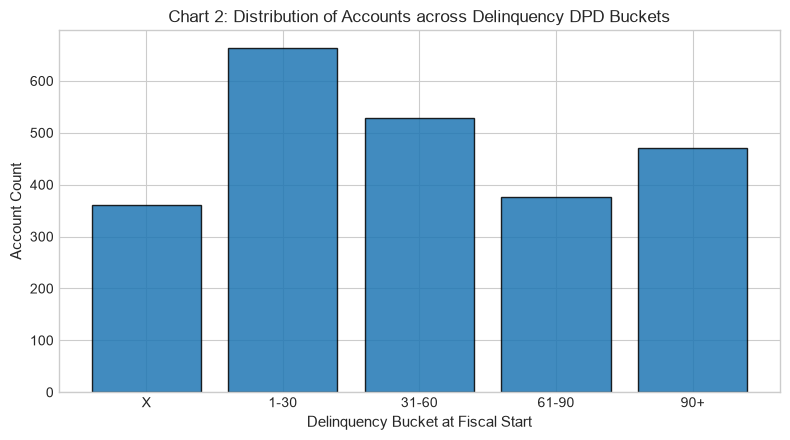

In [3]:
bucket_order = ["X", "1-30", "31-60", "61-90", "90+"]
b_counts = accounts['bucket_start'].value_counts().reindex(bucket_order)
plt.figure(figsize=(8, 4.5))
plt.bar(b_counts.index, b_counts.values, color='#1f77b4', alpha=0.85, edgecolor='black')
plt.title("Chart 2: Distribution of Accounts across Delinquency DPD Buckets")
plt.xlabel("Delinquency Bucket at Fiscal Start")
plt.ylabel("Account Count")
plt.tight_layout()
plt.show()


### Chart 3: Days Past Due (DPD) vs. Mean Overdue Amount


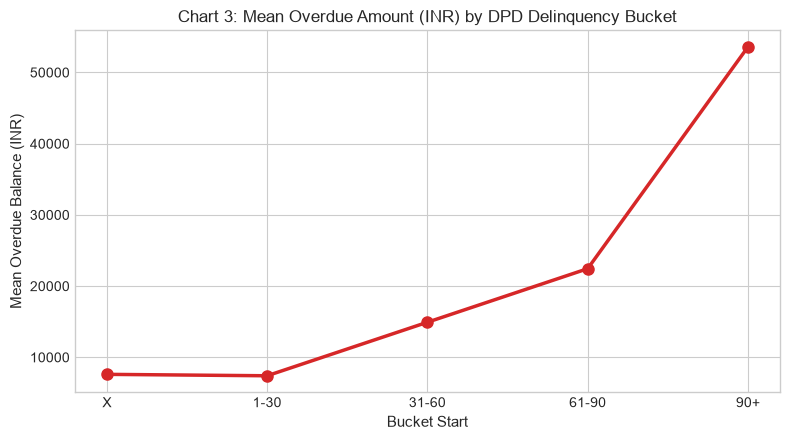

In [4]:
dpd_summary = accounts.groupby('bucket_start')['overdue_start'].mean().reindex(bucket_order)
plt.figure(figsize=(8, 4.5))
plt.plot(dpd_summary.index, dpd_summary.values, marker='o', lw=2.5, color='#d62728', markersize=8)
plt.title("Chart 3: Mean Overdue Amount (INR) by DPD Delinquency Bucket")
plt.xlabel("Bucket Start")
plt.ylabel("Mean Overdue Balance (INR)")
plt.tight_layout()
plt.show()


### Chart 4: Bureau Score Band Distribution


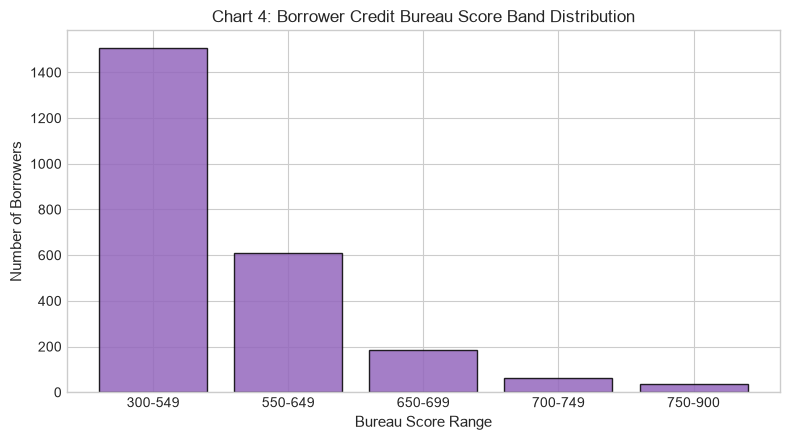

In [5]:
score_order = ["300-549", "550-649", "650-699", "700-749", "750-900"]
s_counts = accounts['bureau_score_band'].value_counts().reindex(score_order)
plt.figure(figsize=(8, 4.5))
plt.bar(s_counts.index, s_counts.values, color='#9467bd', alpha=0.85, edgecolor='black')
plt.title("Chart 4: Borrower Credit Bureau Score Band Distribution")
plt.xlabel("Bureau Score Range")
plt.ylabel("Number of Borrowers")
plt.tight_layout()
plt.show()


### Chart 5: Income Type Composition (Salaried vs. Self-Employed vs. Daily Wage)


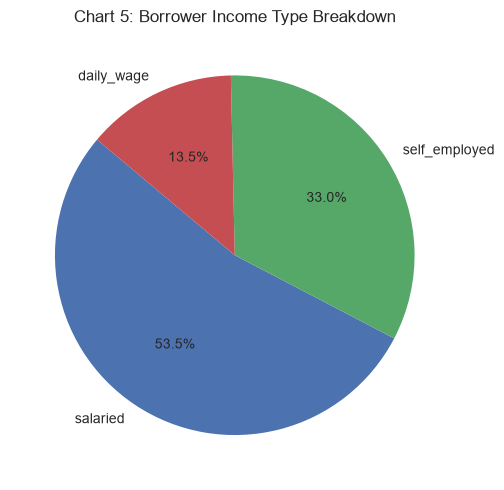

In [6]:
inc_counts = accounts['income_type'].value_counts()
plt.figure(figsize=(6.5, 5))
plt.pie(inc_counts.values, labels=inc_counts.index, autopct='%1.1f%%', colors=['#4c72b0', '#55a868', '#c44e52'], startangle=140)
plt.title("Chart 5: Borrower Income Type Breakdown")
plt.tight_layout()
plt.show()


### Chart 6: Ability-to-Pay (ATP) Estimate Distribution & Missingness


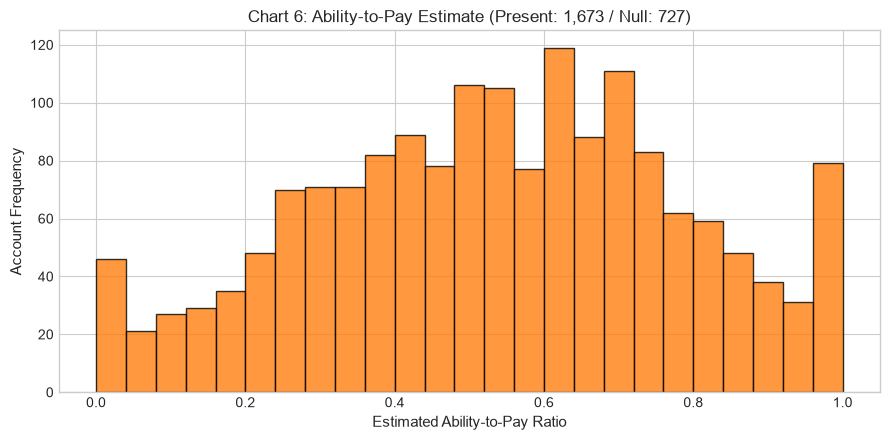

In [7]:
atp = accounts['ability_to_pay_estimate'].dropna()
plt.figure(figsize=(9, 4.5))
plt.hist(atp, bins=25, color='#ff7f0e', alpha=0.8, edgecolor='black')
plt.title(f"Chart 6: Ability-to-Pay Estimate (Present: {len(atp):,d} / Null: {accounts['ability_to_pay_estimate'].isna().sum():,d})")
plt.xlabel("Estimated Ability-to-Pay Ratio")
plt.ylabel("Account Frequency")
plt.tight_layout()
plt.show()


### Chart 7: Salary Credit Day Distribution (Informal vs Banking Timing)


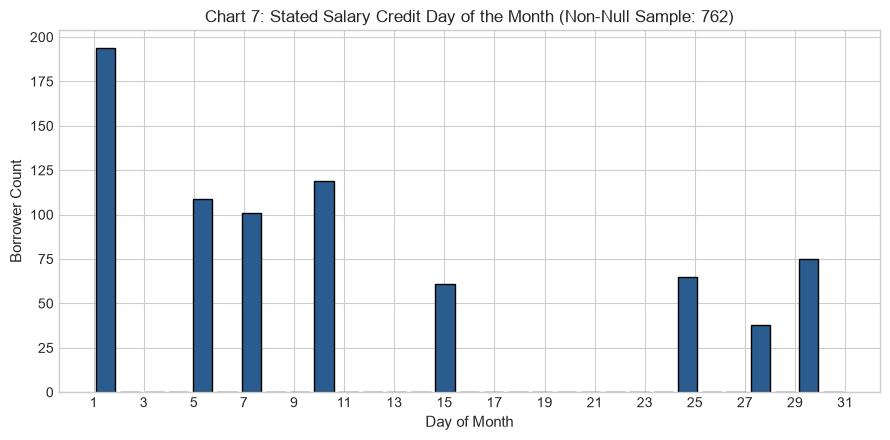

In [8]:
sal_days = accounts['salary_credit_day'].dropna()
plt.figure(figsize=(9, 4.5))
plt.hist(sal_days, bins=31, range=(1, 31), color='#2b5c8f', edgecolor='black', rwidth=0.8)
plt.title(f"Chart 7: Stated Salary Credit Day of the Month (Non-Null Sample: {len(sal_days):,d})")
plt.xlabel("Day of Month")
plt.ylabel("Borrower Count")
plt.xticks(range(1, 32, 2))
plt.tight_layout()
plt.show()


### Chart 8: Outstanding Balance vs. Overdue Amount Hexbin


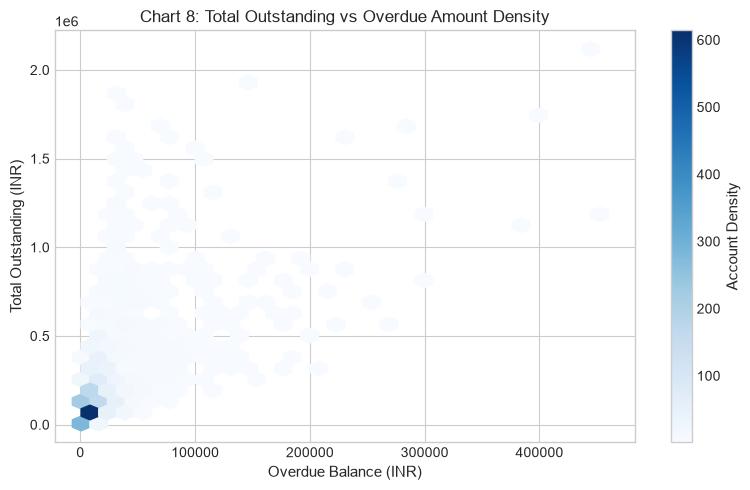

In [9]:
plt.figure(figsize=(8, 5))
hb = plt.hexbin(accounts['overdue_start'], accounts['outstanding'], gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(hb, label='Account Density')
plt.title("Chart 8: Total Outstanding vs Overdue Amount Density")
plt.xlabel("Overdue Balance (INR)")
plt.ylabel("Total Outstanding (INR)")
plt.tight_layout()
plt.show()


### Chart 9: Loan Mandate Bounce Reason Frequency


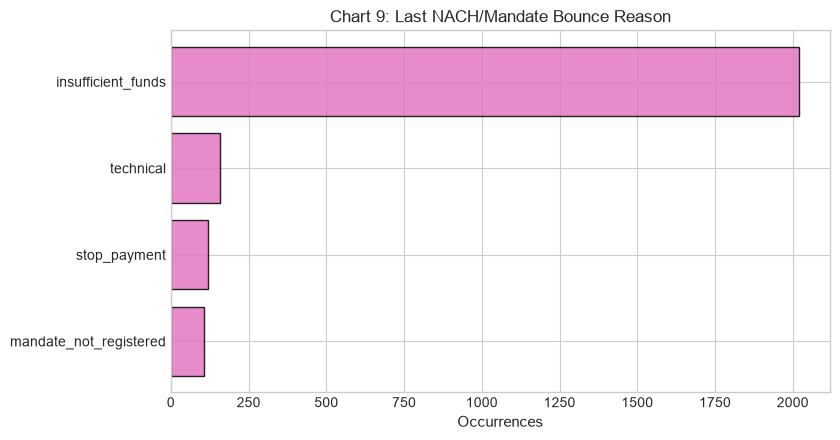

In [10]:
bounces = accounts['last_bounce_reason'].value_counts()
plt.figure(figsize=(8.5, 4.5))
plt.barh(bounces.index, bounces.values, color='#e377c2', alpha=0.85, edgecolor='black')
plt.title("Chart 9: Last NACH/Mandate Bounce Reason")
plt.xlabel("Occurrences")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Chart 10: Lender Loan Volume & Average Overdue Comparison


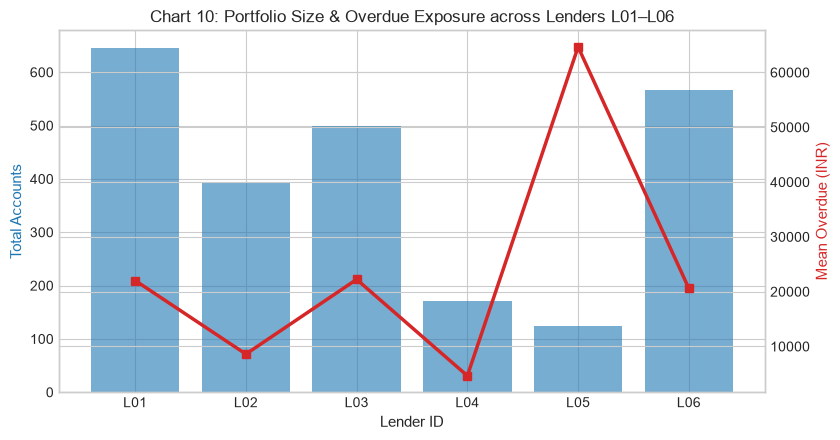

In [11]:
len_summary = accounts.groupby('lender_id').agg(count=('account_id', 'count'), mean_overdue=('overdue_start', 'mean'))
fig, ax1 = plt.subplots(figsize=(8.5, 4.5))
ax2 = ax1.twinx()
ax1.bar(len_summary.index, len_summary['count'], color='#1f77b4', alpha=0.6, label='Account Count')
ax2.plot(len_summary.index, len_summary['mean_overdue'], color='#d62728', marker='s', lw=2.5, label='Mean Overdue (INR)')
ax1.set_xlabel("Lender ID")
ax1.set_ylabel("Total Accounts", color='#1f77b4')
ax2.set_ylabel("Mean Overdue (INR)", color='#d62728')
plt.title("Chart 10: Portfolio Size & Overdue Exposure across Lenders L01–L06")
plt.tight_layout()
plt.show()


### Chart 11: Telephony Network Response Distribution (51k Dials)


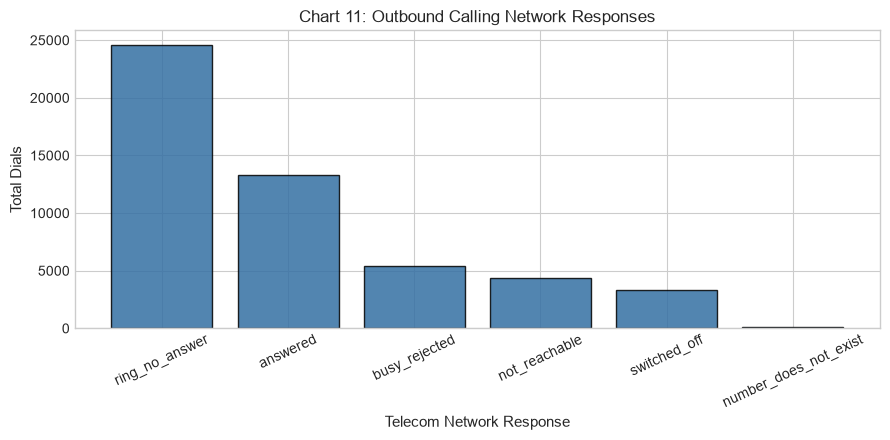

In [12]:
net_resp = dial_attempts['network_response'].value_counts()
plt.figure(figsize=(9, 4.5))
plt.bar(net_resp.index, net_resp.values, color='#3470a3', alpha=0.85, edgecolor='black')
plt.title("Chart 11: Outbound Calling Network Responses")
plt.xlabel("Telecom Network Response")
plt.ylabel("Total Dials")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


### Chart 12: Talk Duration Distribution on Connected Calls


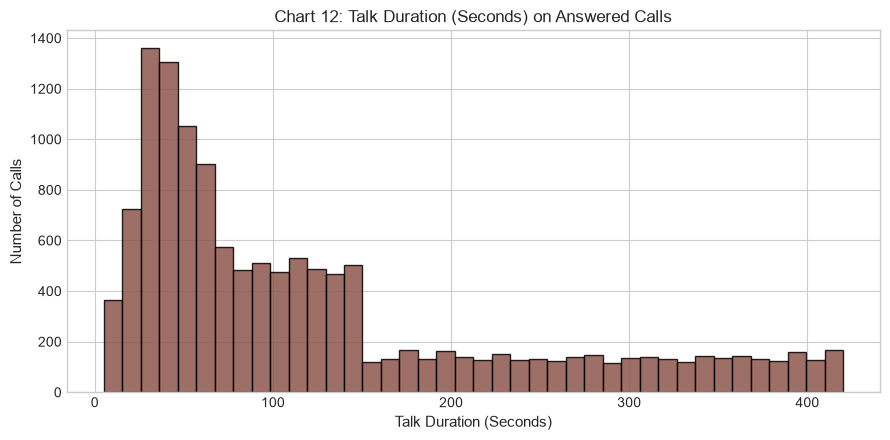

In [13]:
talk_dur = dial_attempts[dial_attempts['talk_duration_s'] > 0]['talk_duration_s']
plt.figure(figsize=(9, 4.5))
plt.hist(talk_dur, bins=40, color='#8c564b', alpha=0.85, edgecolor='black')
plt.title("Chart 12: Talk Duration (Seconds) on Answered Calls")
plt.xlabel("Talk Duration (Seconds)")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()


### Chart 13: Outbound Dials by Hour of Day (Operational Calling Windows)


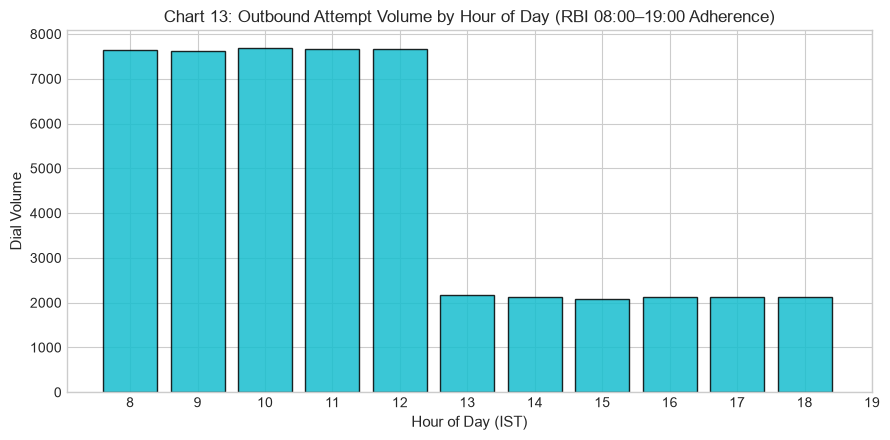

In [14]:
dial_attempts['hour'] = pd.to_datetime(dial_attempts['attempt_ts']).dt.hour
hr_counts = dial_attempts['hour'].value_counts().sort_index()
plt.figure(figsize=(9, 4.5))
plt.bar(hr_counts.index, hr_counts.values, color='#17becf', alpha=0.85, edgecolor='black')
plt.title("Chart 13: Outbound Attempt Volume by Hour of Day (RBI 08:00–19:00 Adherence)")
plt.xlabel("Hour of Day (IST)")
plt.ylabel("Dial Volume")
plt.xticks(range(8, 20))
plt.tight_layout()
plt.show()


### Chart 14: Answer Rate by Day of Week


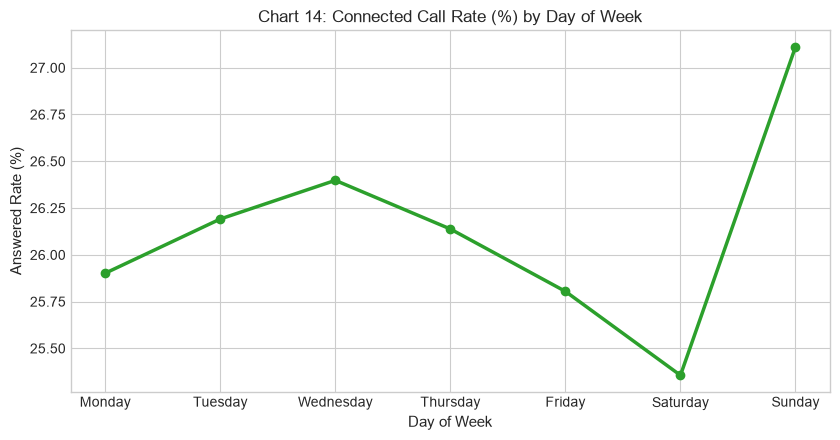

In [15]:
dial_attempts['dow'] = pd.to_datetime(dial_attempts['attempt_ts']).dt.day_name()
order_dow = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
ans_rate = dial_attempts.groupby('dow')['network_response'].apply(lambda x: (x == 'answered').mean()).reindex(order_dow)
plt.figure(figsize=(8.5, 4.5))
plt.plot(ans_rate.index, ans_rate.values * 100, marker='o', lw=2.5, color='#2ca02c')
plt.title("Chart 14: Connected Call Rate (%) by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Answered Rate (%)")
plt.tight_layout()
plt.show()


### Chart 15: The Rogue Agent Audit: Ghost PTPs Logged on Unanswered Calls


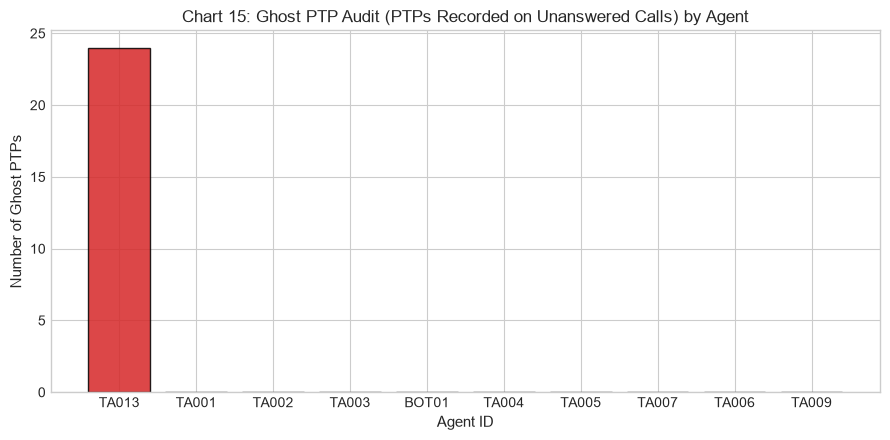

In [16]:
ghosts = dial_attempts[dial_attempts['ptp_id'].notna()].groupby('agent_id')['network_response'].apply(lambda s: (s != 'answered').sum()).sort_values(ascending=False).head(10)
plt.figure(figsize=(9, 4.5))
plt.bar(ghosts.index, ghosts.values, color='#d62728', alpha=0.85, edgecolor='black')
plt.title("Chart 15: Ghost PTP Audit (PTPs Recorded on Unanswered Calls) by Agent")
plt.xlabel("Agent ID")
plt.ylabel("Number of Ghost PTPs")
plt.tight_layout()
plt.show()


### Chart 16: Tele-Agent Keep Rate vs. Tenure Months


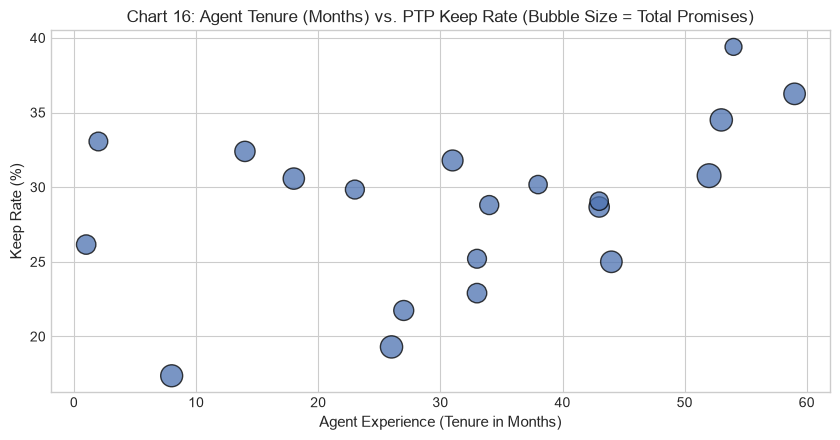

In [17]:
agent_ptp = ptps[ptps['channel'] == 'tele_agent'].groupby('agent_id').agg(keep_rate=('target_kept', 'mean'), count=('ptp_id', 'count')).reset_index()
agent_ptp = agent_ptp.merge(agents[['agent_id', 'tenure_months']], on='agent_id')
plt.figure(figsize=(8.5, 4.5))
plt.scatter(agent_ptp['tenure_months'], agent_ptp['keep_rate'] * 100, s=agent_ptp['count']*1.5, color='#4c72b0', alpha=0.75, edgecolors='black')
plt.title("Chart 16: Agent Tenure (Months) vs. PTP Keep Rate (Bubble Size = Total Promises)")
plt.xlabel("Agent Experience (Tenure in Months)")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 17: Call Dispositions Frequency across Dials


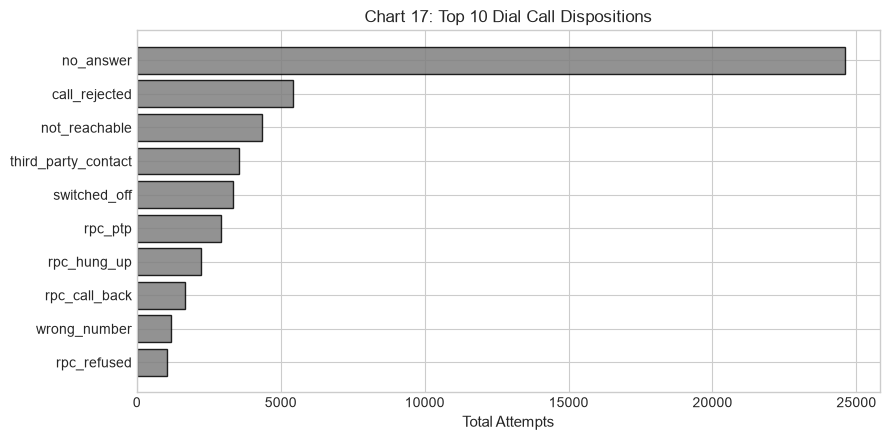

In [18]:
disps = dial_attempts['disposition'].value_counts().head(10)
plt.figure(figsize=(9, 4.5))
plt.barh(disps.index, disps.values, color='#7f7f7f', alpha=0.85, edgecolor='black')
plt.title("Chart 17: Top 10 Dial Call Dispositions")
plt.xlabel("Total Attempts")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Chart 18: Ring Duration Comparison across Network Responses


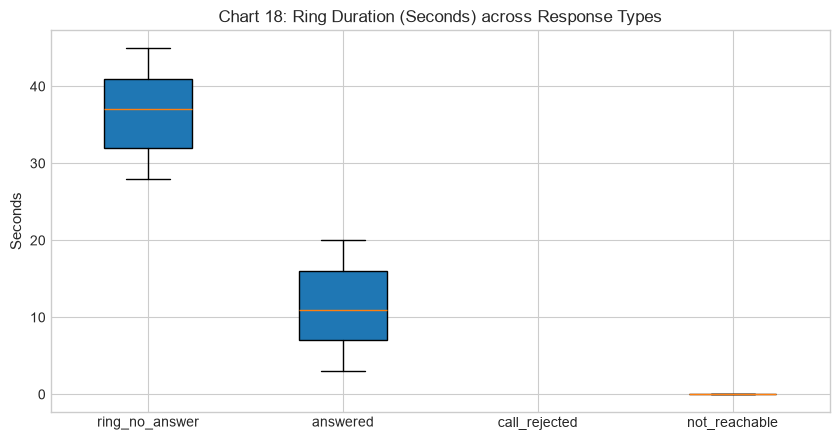

In [19]:
resp_order = ['ring_no_answer', 'answered', 'call_rejected', 'not_reachable']
box_data = [dial_attempts[dial_attempts['network_response'] == r]['ring_duration_s'].dropna() for r in resp_order]
plt.figure(figsize=(8.5, 4.5))
plt.boxplot(box_data, tick_labels=resp_order, patch_artist=True)
plt.title("Chart 18: Ring Duration (Seconds) across Response Types")
plt.ylabel("Seconds")
plt.tight_layout()
plt.show()


### Chart 19: Call Disconnect Initiator Breakdown


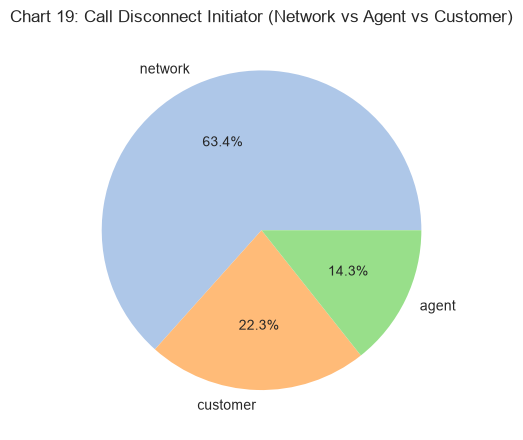

In [20]:
hangup = dial_attempts['hangup_by'].value_counts()
plt.figure(figsize=(6, 4.5))
plt.pie(hangup.values, labels=hangup.index, autopct='%1.1f%%', colors=['#aec7e8', '#ffbb78', '#98df8a'])
plt.title("Chart 19: Call Disconnect Initiator (Network vs Agent vs Customer)")
plt.tight_layout()
plt.show()


### Chart 20: Top 10 Tele-Agent Dispositions on Connected Calls


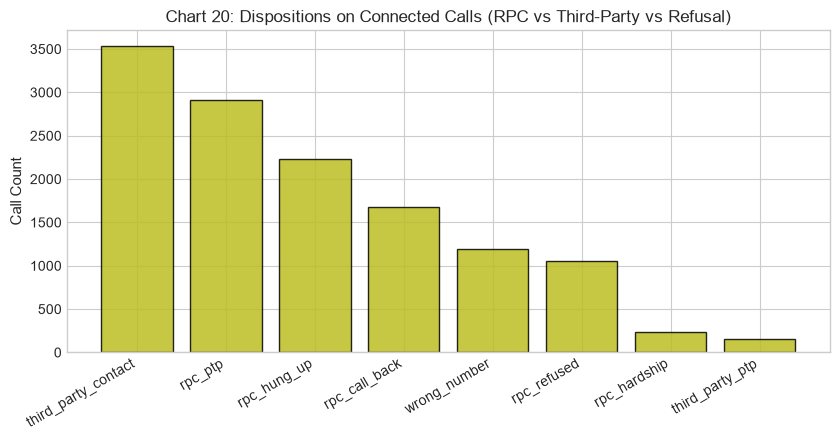

In [21]:
connected_disp = dial_attempts[dial_attempts['network_response'] == 'answered']['disposition'].value_counts().head(8)
plt.figure(figsize=(8.5, 4.5))
plt.bar(connected_disp.index, connected_disp.values, color='#bcbd22', alpha=0.85, edgecolor='black')
plt.title("Chart 20: Dispositions on Connected Calls (RPC vs Third-Party vs Refusal)")
plt.xticks(rotation=30, ha='right')
plt.ylabel("Call Count")
plt.tight_layout()
plt.show()


### Chart 21: Turn Count Distribution in Call Transcripts


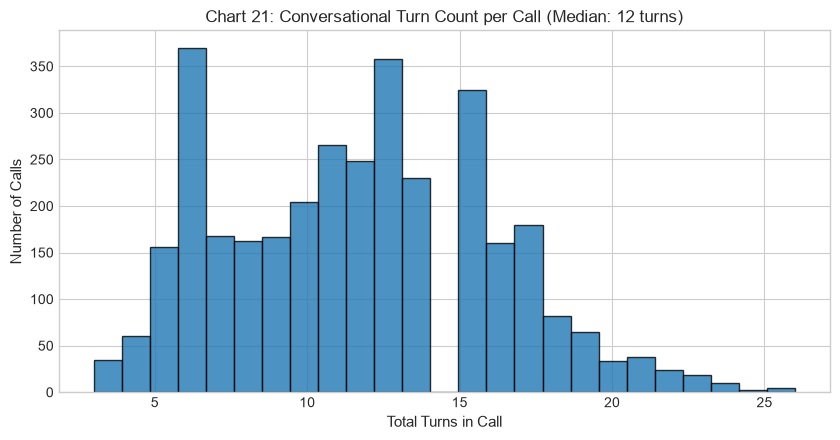

In [22]:
turns_per_call = transcripts.groupby('call_id')['turn_idx'].count()
plt.figure(figsize=(8.5, 4.5))
plt.hist(turns_per_call, bins=25, color='#1f77b4', alpha=0.8, edgecolor='black')
plt.title(f"Chart 21: Conversational Turn Count per Call (Median: {turns_per_call.median():.0f} turns)")
plt.xlabel("Total Turns in Call")
plt.ylabel("Number of Calls")
plt.tight_layout()
plt.show()


### Chart 22: Customer Speech Pause Latency Distribution


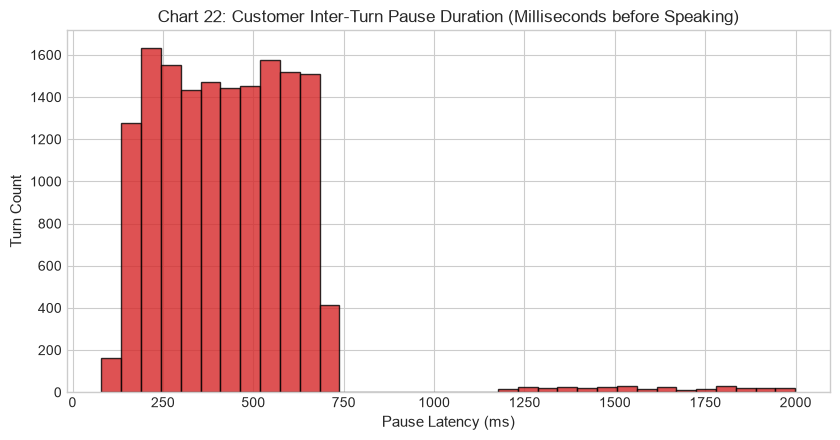

In [23]:
cust_pauses = transcripts[transcripts['speaker'] == 'customer']['pause_before_ms'].dropna()
plt.figure(figsize=(8.5, 4.5))
plt.hist(cust_pauses[cust_pauses <= 2000], bins=35, color='#d62728', alpha=0.8, edgecolor='black')
plt.title("Chart 22: Customer Inter-Turn Pause Duration (Milliseconds before Speaking)")
plt.xlabel("Pause Latency (ms)")
plt.ylabel("Turn Count")
plt.tight_layout()
plt.show()


### Chart 23: Response Pause Latency Quartile vs. PTP Keep Rate


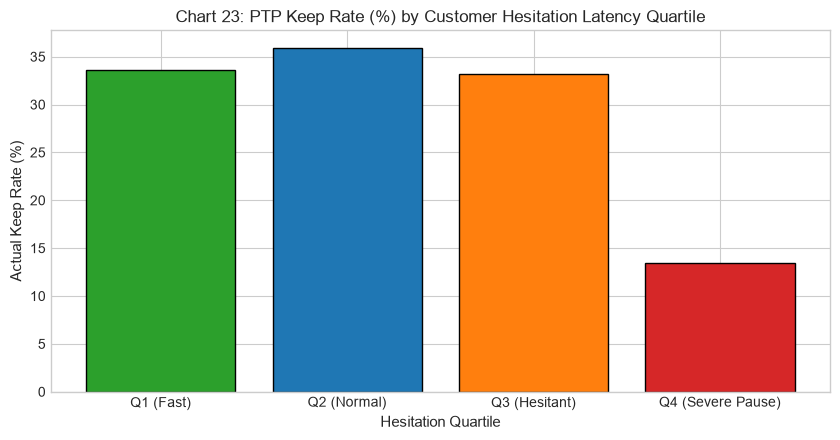

In [24]:
call_pause = transcripts[transcripts['speaker'] == 'customer'].groupby('call_id')['pause_before_ms'].mean()
ptp_pause = ptps.merge(call_pause.rename('mean_pause'), left_on='attempt_id', right_index=True)
ptp_pause['pause_bin'] = pd.qcut(ptp_pause['mean_pause'], q=4, labels=['Q1 (Fast)', 'Q2 (Normal)', 'Q3 (Hesitant)', 'Q4 (Severe Pause)'])
pause_keep = ptp_pause.groupby('pause_bin', observed=False)['target_kept'].mean() * 100
plt.figure(figsize=(8.5, 4.5))
plt.bar(pause_keep.index, pause_keep.values, color=['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728'], edgecolor='black')
plt.title("Chart 23: PTP Keep Rate (%) by Customer Hesitation Latency Quartile")
plt.xlabel("Hesitation Quartile")
plt.ylabel("Actual Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 24: Customer Word Share vs. Agent Word Share


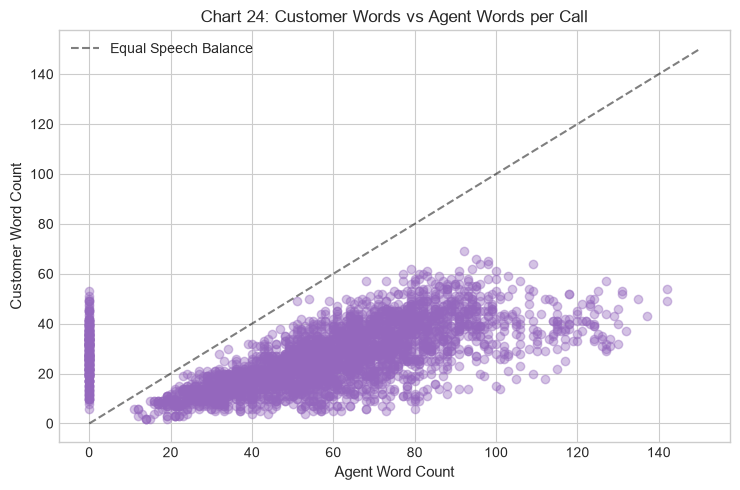

In [25]:
speaker_words = transcripts.groupby(['call_id', 'speaker'])['text'].apply(lambda s: s.str.split().str.len().sum()).unstack(fill_value=0)
plt.figure(figsize=(7.5, 5))
plt.scatter(speaker_words.get('agent', 0), speaker_words.get('customer', 0), alpha=0.4, color='#9467bd')
plt.plot([0, 150], [0, 150], 'k--', alpha=0.5, label='Equal Speech Balance')
plt.title("Chart 24: Customer Words vs Agent Words per Call")
plt.xlabel("Agent Word Count")
plt.ylabel("Customer Word Count")
plt.legend()
plt.tight_layout()
plt.show()


### Chart 25: ASR Transcription Confidence by Speaker


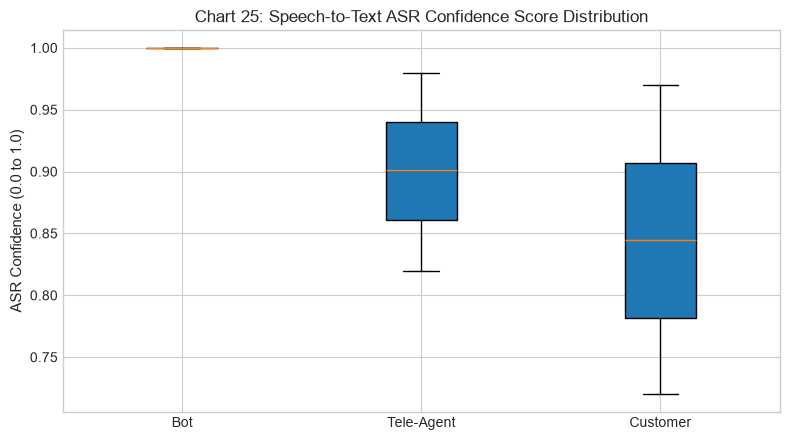

In [26]:
asr_conf = [transcripts[transcripts['speaker'] == sp]['asr_confidence'].dropna() for sp in ['bot', 'agent', 'customer']]
plt.figure(figsize=(8, 4.5))
plt.boxplot(asr_conf, tick_labels=['Bot', 'Tele-Agent', 'Customer'], patch_artist=True)
plt.title("Chart 25: Speech-to-Text ASR Confidence Score Distribution")
plt.ylabel("ASR Confidence (0.0 to 1.0)")
plt.tight_layout()
plt.show()


### Chart 26: Call Language Mix (Hinglish vs Kanglish vs English)


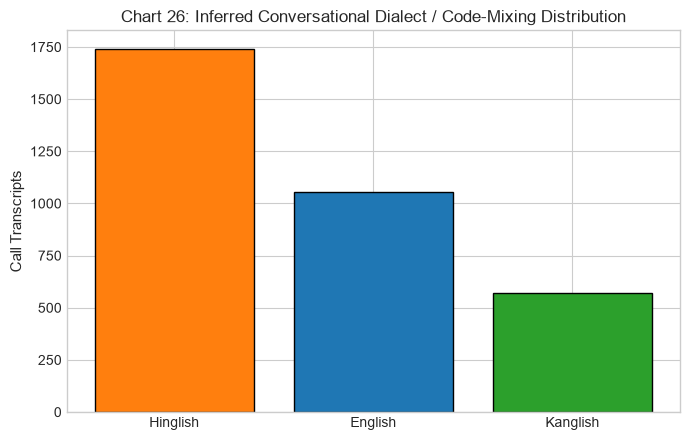

In [27]:
c_text = transcripts.groupby('call_id')['text'].apply(lambda s: " ".join(s.astype(str)))
langs = c_text.apply(lambda t: 'Hinglish' if ('hai' in t or 'karo' in t) else ('Kanglish' if ('madi' in t or 'illa' in t) else 'English')).value_counts()
plt.figure(figsize=(7, 4.5))
plt.bar(langs.index, langs.values, color=['#ff7f0e', '#1f77b4', '#2ca02c'], edgecolor='black')
plt.title("Chart 26: Inferred Conversational Dialect / Code-Mixing Distribution")
plt.ylabel("Call Transcripts")
plt.tight_layout()
plt.show()


### Chart 27: Verbal Hedging vs. Keep Rate


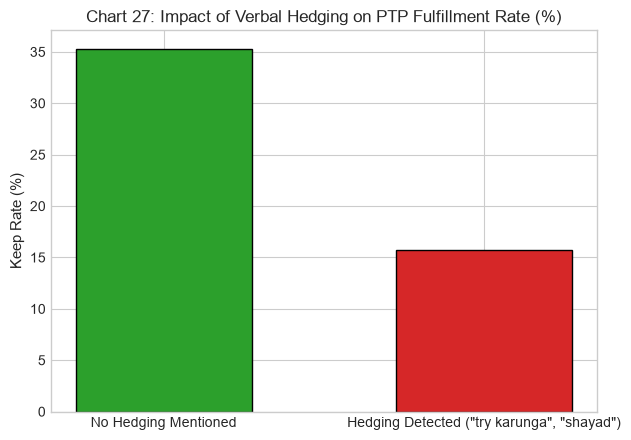

In [28]:
hedge_rx = re.compile(r"(shayad|maybe|\btry\b|koshish|dekhta hoon|nodtini)", re.I)
c_text_df = transcripts[transcripts['speaker'] == 'customer'].groupby('call_id')['text'].apply(lambda s: " ".join(s)).reset_index()
c_text_df['has_hedge'] = c_text_df['text'].apply(lambda t: bool(hedge_rx.search(t))).astype(int)
ptp_hedge = ptps.merge(c_text_df[['call_id', 'has_hedge']], left_on='attempt_id', right_on='call_id')
hedge_rate = ptp_hedge.groupby('has_hedge')['target_kept'].mean() * 100
plt.figure(figsize=(6.5, 4.5))
plt.bar(['No Hedging Mentioned', 'Hedging Detected ("try karunga", "shayad")'], hedge_rate.values, color=['#2ca02c', '#d62728'], edgecolor='black', width=0.55)
plt.title("Chart 27: Impact of Verbal Hedging on PTP Fulfillment Rate (%)")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 28: Verbal Commitment Markers vs. Keep Rate


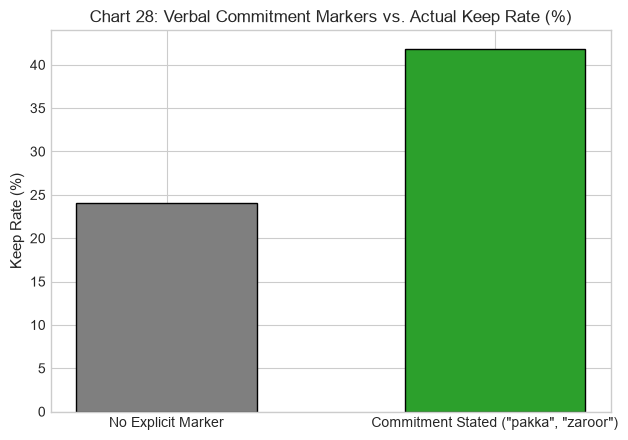

In [29]:
commit_rx = re.compile(r"(pakka|confirmed?|definitely|guarantee|100 ?%|zaroor|khud kar dunga)", re.I)
c_text_df['has_commit'] = c_text_df['text'].apply(lambda t: bool(commit_rx.search(t))).astype(int)
ptp_commit = ptps.merge(c_text_df[['call_id', 'has_commit']], left_on='attempt_id', right_on='call_id')
commit_rate = ptp_commit.groupby('has_commit')['target_kept'].mean() * 100
plt.figure(figsize=(6.5, 4.5))
plt.bar(['No Explicit Marker', 'Commitment Stated ("pakka", "zaroor")'], commit_rate.values, color=['#7f7f7f', '#2ca02c'], edgecolor='black', width=0.55)
plt.title("Chart 28: Verbal Commitment Markers vs. Actual Keep Rate (%)")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 29: Escape & Call Termination Keywords Prevalence


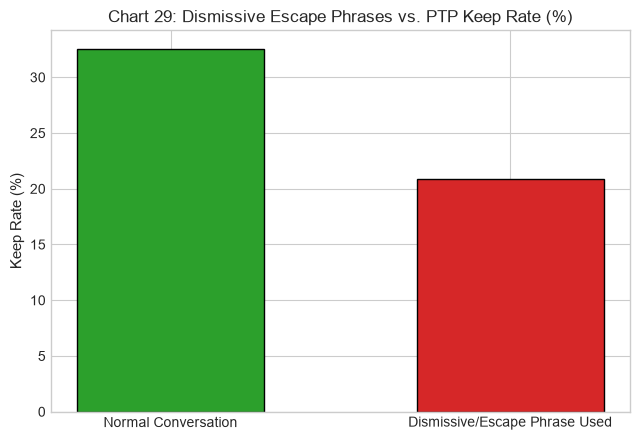

In [30]:
escape_rx = re.compile(r"(baad mein call|call later|meeting|busy|abhi nahi ho)", re.I)
c_text_df['has_escape'] = c_text_df['text'].apply(lambda t: bool(escape_rx.search(t))).astype(int)
ptp_escape = ptps.merge(c_text_df[['call_id', 'has_escape']], left_on='attempt_id', right_on='call_id')
escape_rate = ptp_escape.groupby('has_escape')['target_kept'].mean() * 100
plt.figure(figsize=(6.5, 4.5))
plt.bar(['Normal Conversation', 'Dismissive/Escape Phrase Used'], escape_rate.values, color=['#2ca02c', '#d62728'], edgecolor='black', width=0.55)
plt.title("Chart 29: Dismissive Escape Phrases vs. PTP Keep Rate (%)")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 30: Hardship Keyword Mentions across Delinquency Buckets


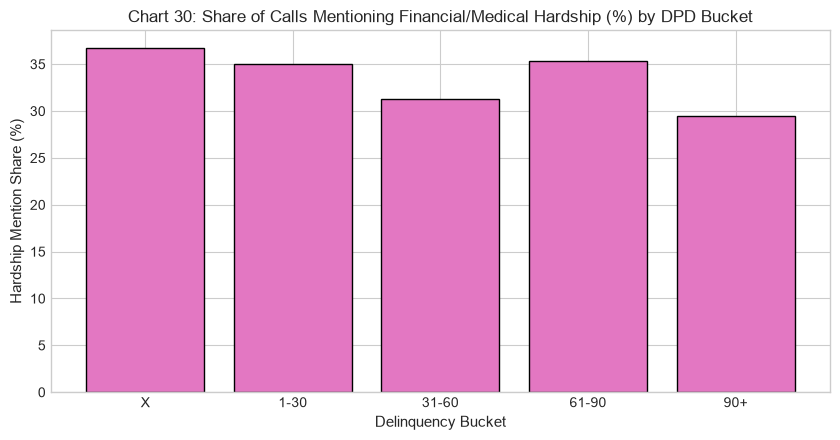

In [31]:
hardship_rx = re.compile(r"(salary|paise nahi|no money|hospital|admit|job gaya|medical)", re.I)
c_text_df['has_hardship'] = c_text_df['text'].apply(lambda t: bool(hardship_rx.search(t))).astype(int)
hardship_acc = ptps.merge(c_text_df[['call_id', 'has_hardship']], left_on='attempt_id', right_on='call_id').merge(accounts[['account_id', 'bucket_start']], on='account_id')
hard_share = hardship_acc.groupby('bucket_start')['has_hardship'].mean().reindex(bucket_order) * 100
plt.figure(figsize=(8.5, 4.5))
plt.bar(hard_share.index, hard_share.values, color='#e377c2', edgecolor='black')
plt.title("Chart 30: Share of Calls Mentioning Financial/Medical Hardship (%) by DPD Bucket")
plt.xlabel("Delinquency Bucket")
plt.ylabel("Hardship Mention Share (%)")
plt.tight_layout()
plt.show()


### Chart 31: Who Proposed the Promise Date First? (Negotiation Dynamics)


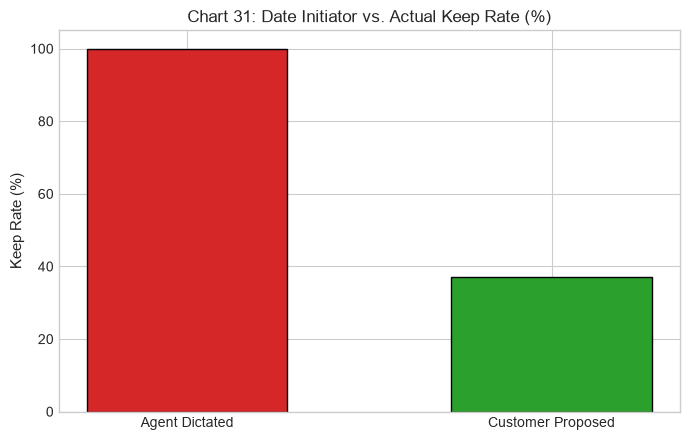

In [32]:
date_rx = re.compile(r"(\b\d{1,2}\s*(st|nd|rd|th)?\s*(tareekh|tarikh|ko|ne|th)|\bkal\b|next week|month end)", re.I)
first_by = []
for cid, g in transcripts.groupby('call_id'):
    found = 'none'
    for r in g.itertuples():
        if date_rx.search(str(r.text)):
            found = 'customer' if r.speaker == 'customer' else 'agent'
            break
    first_by.append({'call_id': cid, 'first_date': found})
first_df = pd.DataFrame(first_by)
ptp_first = ptps.merge(first_df, left_on='attempt_id', right_on='call_id')
first_perf = ptp_first.groupby('first_date')['target_kept'].agg(keep_rate='mean', n='count')
plt.figure(figsize=(7, 4.5))
plt.bar(['Agent Dictated', 'Customer Proposed'], [first_perf.loc['agent', 'keep_rate']*100, first_perf.loc['customer', 'keep_rate']*100], color=['#d62728', '#2ca02c'], edgecolor='black', width=0.55)
plt.title("Chart 31: Date Initiator vs. Actual Keep Rate (%)")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 32: Customer Stated Amount vs Agent Stated Amount


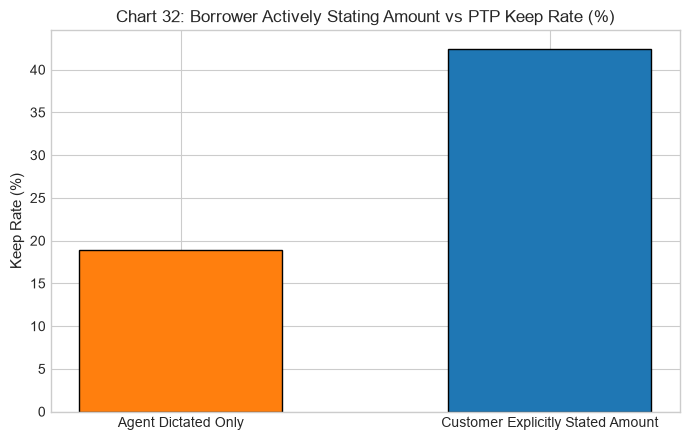

In [33]:
num_rx = re.compile(r"(?:₹|rs\.?\s*|rupees?\s*)?(\d{1,3}(?:,\d{2,3})+|\d{3,7})", re.I)
cust_amt_flag = transcripts[transcripts['speaker'] == 'customer'].groupby('call_id')['text'].apply(lambda s: bool(num_rx.search(" ".join(s)))).reset_index(name='cust_stated_num')
ptp_amt_stat = ptps.merge(cust_amt_flag, left_on='attempt_id', right_on='call_id')
stated_perf = ptp_amt_stat.groupby('cust_stated_num')['target_kept'].mean() * 100
plt.figure(figsize=(7, 4.5))
plt.bar(['Agent Dictated Only', 'Customer Explicitly Stated Amount'], stated_perf.values, color=['#ff7f0e', '#1f77b4'], edgecolor='black', width=0.55)
plt.title("Chart 32: Borrower Actively Stating Amount vs PTP Keep Rate (%)")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 33: Frequency of [inaudible] Turns by ASR Quality


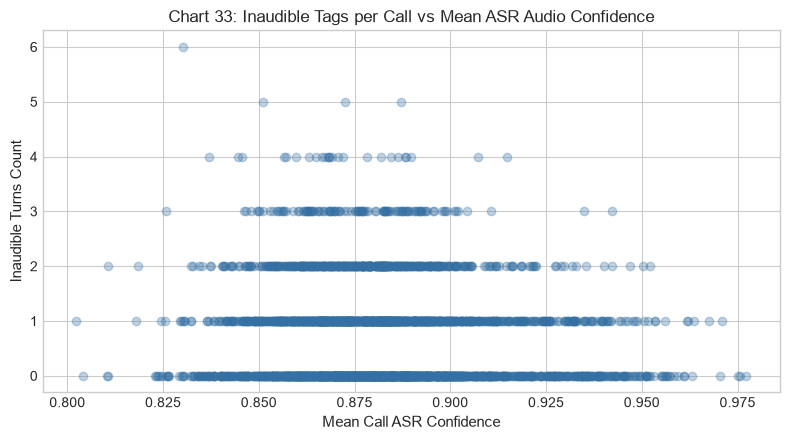

In [34]:
inaud = transcripts.groupby('call_id').agg(inaud_count=('text', lambda s: s.str.contains(r'\[inaudible\]').sum()), mean_asr=('asr_confidence', 'mean'))
plt.figure(figsize=(8, 4.5))
plt.scatter(inaud['mean_asr'], inaud['inaud_count'], alpha=0.3, color='#3470a3')
plt.title("Chart 33: Inaudible Tags per Call vs Mean ASR Audio Confidence")
plt.xlabel("Mean Call ASR Confidence")
plt.ylabel("Inaudible Turns Count")
plt.tight_layout()
plt.show()


### Chart 34: Global PTP Outcome Split (Kept vs Broken Promises)


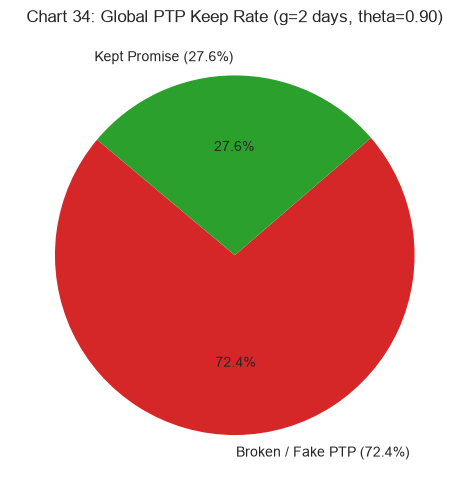

In [35]:
ptp_pie = ptps['target_kept'].value_counts()
plt.figure(figsize=(6, 5))
plt.pie(ptp_pie.values, labels=['Broken / Fake PTP (72.4%)', 'Kept Promise (27.6%)'], autopct='%1.1f%%', colors=['#d62728', '#2ca02c'], startangle=140)
plt.title("Chart 34: Global PTP Keep Rate (g=2 days, theta=0.90)")
plt.tight_layout()
plt.show()


### Chart 35: Sensitivity of Keep Rate to Grace Periods (0, 2, 5 Days) and Thresholds


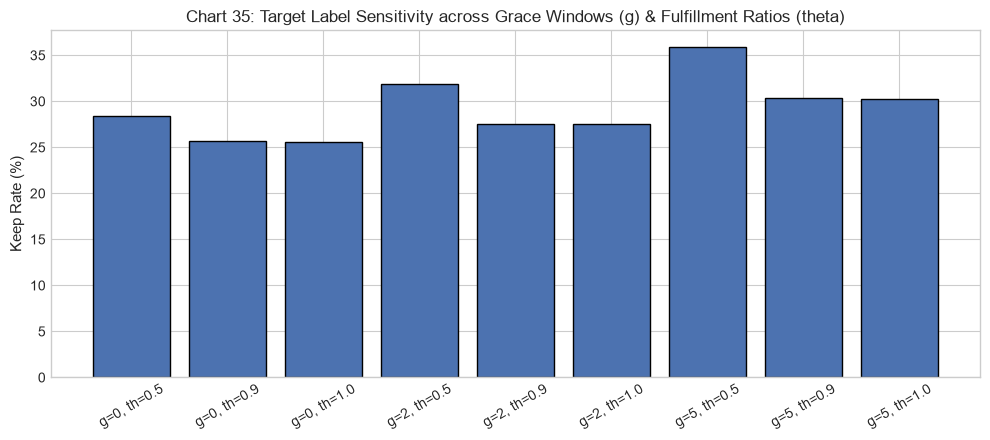

In [36]:
sens_data = {
    'g=0, th=0.5': 28.36, 'g=0, th=0.9': 25.68, 'g=0, th=1.0': 25.63,
    'g=2, th=0.5': 31.85, 'g=2, th=0.9': 27.55, 'g=2, th=1.0': 27.52,
    'g=5, th=0.5': 35.90, 'g=5, th=0.9': 30.32, 'g=5, th=1.0': 30.29,
}
plt.figure(figsize=(10, 4.5))
plt.bar(sens_data.keys(), sens_data.values(), color='#4c72b0', edgecolor='black')
plt.title("Chart 35: Target Label Sensitivity across Grace Windows (g) & Fulfillment Ratios (theta)")
plt.ylabel("Keep Rate (%)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Chart 36: Lead Time (Days until Promised Date) Distribution


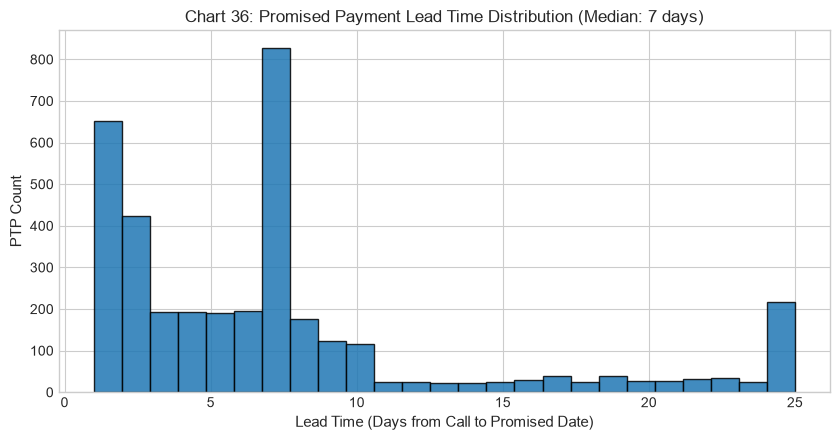

In [37]:
plt.figure(figsize=(8.5, 4.5))
plt.hist(ptps['lead_days'].clip(upper=25), bins=25, color='#1f77b4', alpha=0.85, edgecolor='black')
plt.title("Chart 36: Promised Payment Lead Time Distribution (Median: 7 days)")
plt.xlabel("Lead Time (Days from Call to Promised Date)")
plt.ylabel("PTP Count")
plt.tight_layout()
plt.show()


### Chart 37: Promise Lead Time vs. Empirical Keep Rate (Salary Synchronization vs Escape Promises)


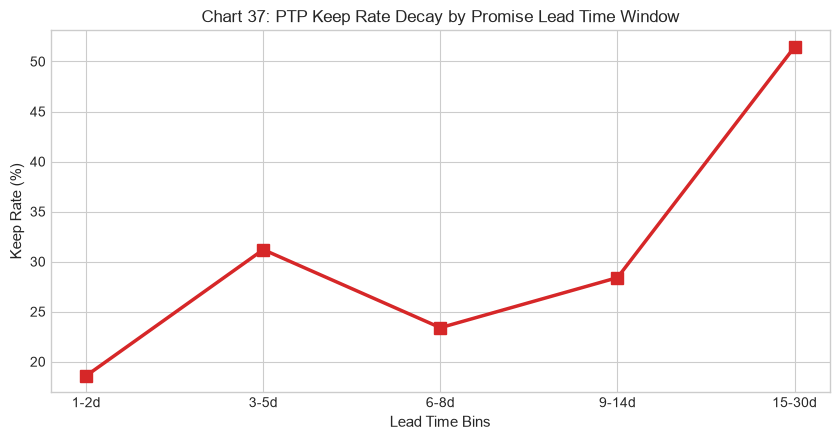

In [38]:
ptps['lead_bin'] = pd.cut(ptps['lead_days'], bins=[0, 2, 5, 8, 14, 30], labels=['1-2d', '3-5d', '6-8d', '9-14d', '15-30d'])
lead_perf = ptps.groupby('lead_bin', observed=False)['target_kept'].mean() * 100
plt.figure(figsize=(8.5, 4.5))
plt.plot(lead_perf.index, lead_perf.values, marker='s', lw=2.5, color='#d62728', markersize=8)
plt.title("Chart 37: PTP Keep Rate vs Promise Lead Time Window")
plt.xlabel("Lead Time Bins")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 38: Promised Amount to Overdue Balance Ratio Distribution


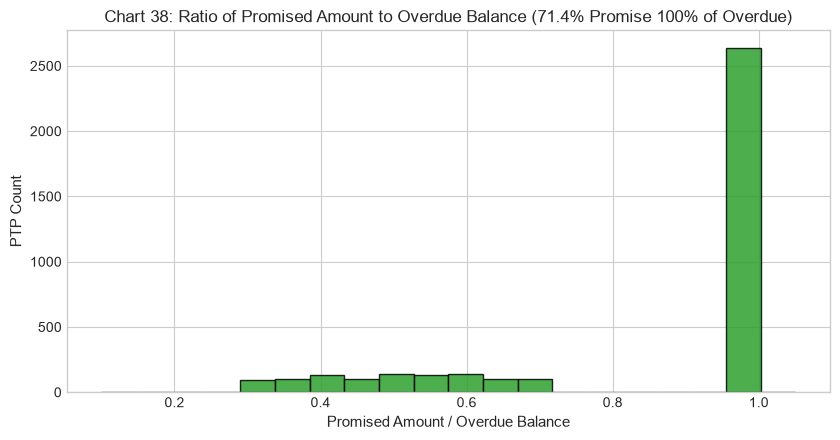

In [39]:
ptps['amt_ratio'] = (ptps['promised_amount'] / ptps['overdue_at_capture'].clip(lower=1.0)).round(2)
plt.figure(figsize=(8.5, 4.5))
plt.hist(ptps['amt_ratio'], bins=20, range=(0.1, 1.05), color='#2ca02c', alpha=0.85, edgecolor='black')
plt.title("Chart 38: Ratio of Promised Amount to Overdue Balance (71.4% Promise 100% of Overdue)")
plt.xlabel("Promised Amount / Overdue Balance")
plt.ylabel("PTP Count")
plt.tight_layout()
plt.show()


### Chart 39: Clustering on Round Numbers (Multiples of ₹500 and ₹1,000)


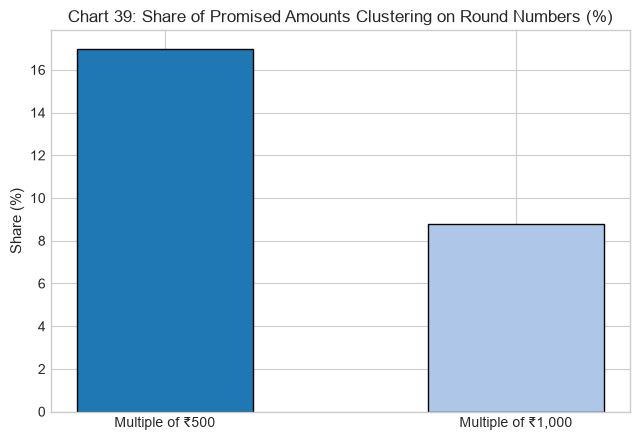

In [40]:
round_1000 = ((ptps['promised_amount'] % 1000) == 0).mean() * 100
round_500 = ((ptps['promised_amount'] % 500) == 0).mean() * 100
plt.figure(figsize=(6.5, 4.5))
plt.bar(['Multiple of ₹500', 'Multiple of ₹1,000'], [round_500, round_1000], color=['#1f77b4', '#aec7e8'], edgecolor='black', width=0.5)
plt.title("Chart 39: Share of Promised Amounts Clustering on Round Numbers (%)")
plt.ylabel("Share (%)")
plt.tight_layout()
plt.show()


### Chart 40: PTP Fulfillment by Contact Channel


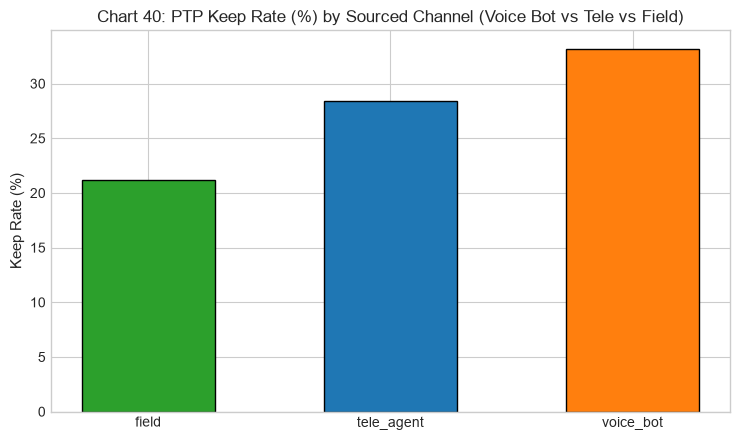

In [41]:
chan_perf = ptps.groupby('channel')['target_kept'].agg(keep_rate='mean', n='count')
plt.figure(figsize=(7.5, 4.5))
plt.bar(chan_perf.index, chan_perf['keep_rate'] * 100, color=['#2ca02c', '#1f77b4', '#ff7f0e'], edgecolor='black', width=0.55)
plt.title("Chart 40: PTP Keep Rate (%) by Sourced Channel (Voice Bot vs Tele vs Field)")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 41: Payment Clumping Relative to Promised Due Date


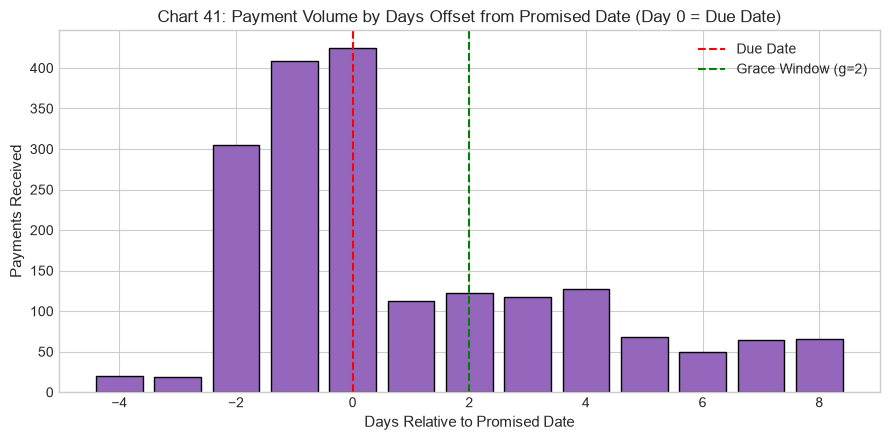

In [42]:
m_pay = ptps.merge(payments, on='account_id')
m_pay['offset_days'] = (m_pay['payment_ts'].dt.normalize() - m_pay['promised_date'].dt.normalize()).dt.days
near_pay = m_pay[m_pay['offset_days'].between(-4, 8)]['offset_days'].value_counts().sort_index()
plt.figure(figsize=(9, 4.5))
plt.bar(near_pay.index, near_pay.values, color='#9467bd', edgecolor='black')
plt.title("Chart 41: Payment Volume by Days Offset from Promised Date (Day 0 = Due Date)")
plt.xlabel("Days Relative to Promised Date")
plt.ylabel("Payments Received")
plt.axvline(x=0, color='r', linestyle='--', label='Due Date')
plt.axvline(x=2, color='g', linestyle='--', label='Grace Window (g=2)')
plt.legend()
plt.tight_layout()
plt.show()


### Chart 42: Cash Recovery Channels (UPI vs NACH vs Branch vs Field)


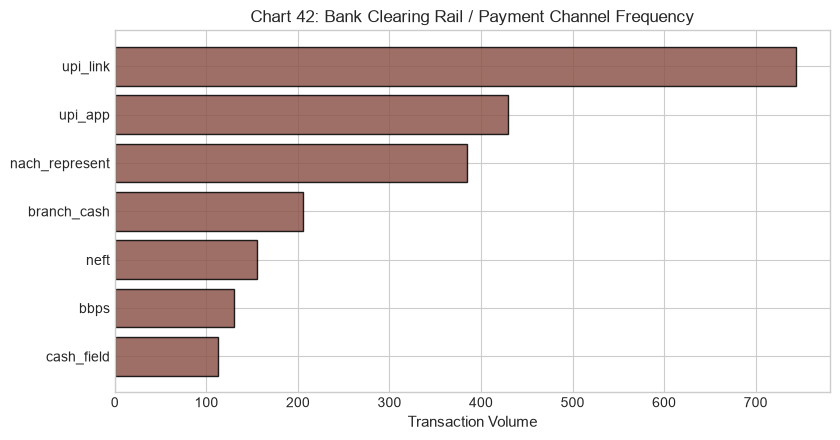

In [43]:
pay_chan = payments['channel'].value_counts()
plt.figure(figsize=(8.5, 4.5))
plt.barh(pay_chan.index, pay_chan.values, color='#8c564b', alpha=0.85, edgecolor='black')
plt.title("Chart 42: Bank Clearing Rail / Payment Channel Frequency")
plt.xlabel("Transaction Volume")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Chart 43: Organic Payers vs. Promise Keepers (Placebo Contrast)


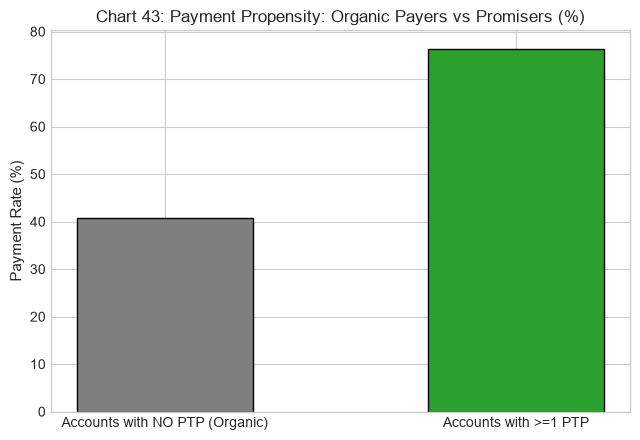

In [44]:
no_ptp_accs = accounts[~accounts['account_id'].isin(ptps['account_id'])]
ptp_accs = accounts[accounts['account_id'].isin(ptps['account_id'])]
paid_no_ptp = no_ptp_accs['account_id'].isin(payments['account_id']).mean() * 100
paid_with_ptp = ptp_accs['account_id'].isin(payments['account_id']).mean() * 100
plt.figure(figsize=(6.5, 4.5))
plt.bar(['Accounts with NO PTP (Organic)', 'Accounts with >=1 PTP'], [paid_no_ptp, paid_with_ptp], color=['#7f7f7f', '#2ca02c'], edgecolor='black', width=0.5)
plt.title("Chart 43: Payment Propensity: Organic Payers vs Promisers (%)")
plt.ylabel("Payment Rate (%)")
plt.tight_layout()
plt.show()


### Chart 44: Post-Call Digital Engagement Event Funnel


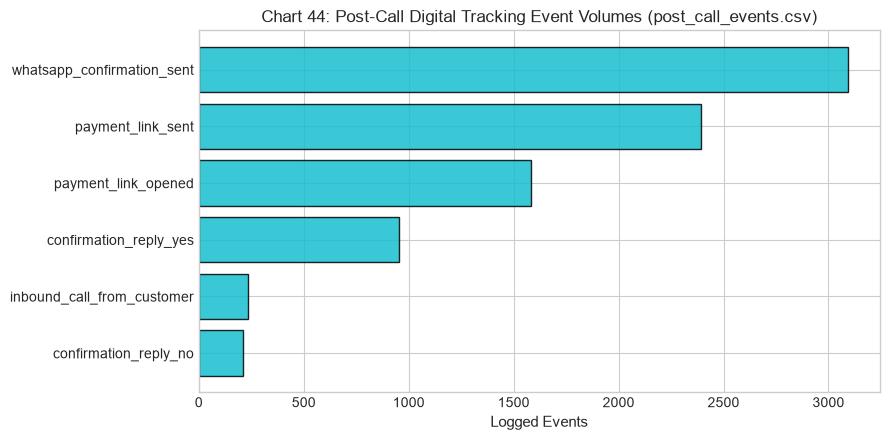

In [45]:
pce_counts = post_call['event_type'].value_counts()
plt.figure(figsize=(9, 4.5))
plt.barh(pce_counts.index, pce_counts.values, color='#17becf', alpha=0.85, edgecolor='black')
plt.title("Chart 44: Post-Call Digital Tracking Event Volumes (post_call_events.csv)")
plt.xlabel("Logged Events")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### Chart 45: Payment Link Time-to-Open Density (Hours after Call)


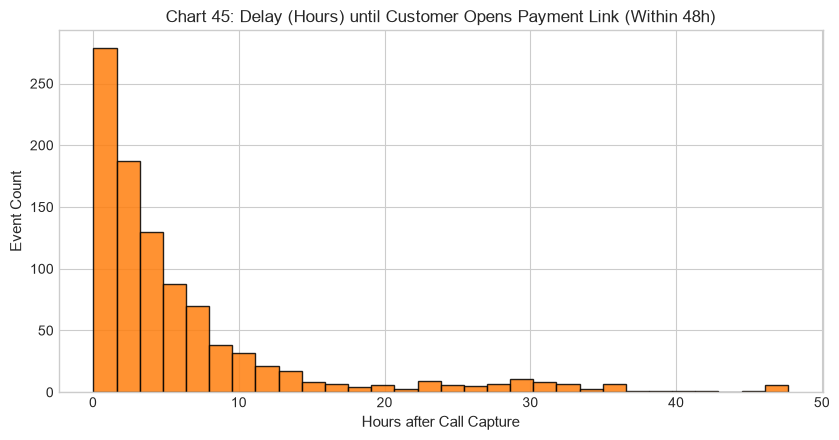

In [46]:
link_opens = post_call[post_call['event_type'] == 'payment_link_opened'].merge(ptps[['ptp_id', 'captured_ts']], on='ptp_id')
link_opens['delay_h'] = (pd.to_datetime(link_opens['event_ts']) - pd.to_datetime(link_opens['captured_ts'])).dt.total_seconds() / 3600.0
valid_delays = link_opens[link_opens['delay_h'].between(0, 48)]['delay_h']
plt.figure(figsize=(8.5, 4.5))
plt.hist(valid_delays, bins=30, color='#ff7f0e', alpha=0.85, edgecolor='black')
plt.title("Chart 45: Delay (Hours) until Customer Opens Payment Link (Within 48h)")
plt.xlabel("Hours after Call Capture")
plt.ylabel("Event Count")
plt.tight_layout()
plt.show()


### Chart 46: Payment Link Open Status vs. PTP Fulfillment


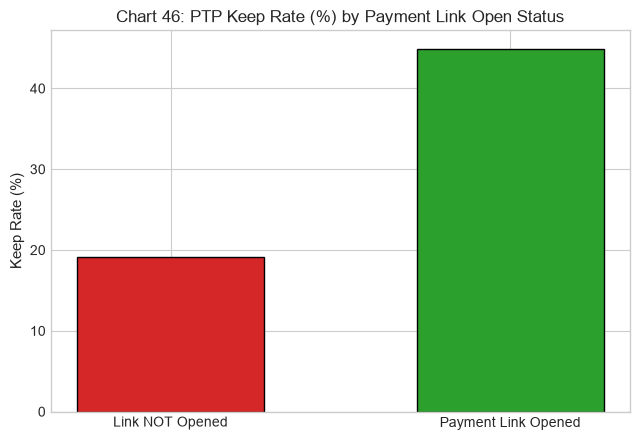

In [47]:
ptps_opened = ptps.copy()
ptps_opened['opened_link'] = ptps_opened['ptp_id'].isin(post_call[post_call['event_type'] == 'payment_link_opened']['ptp_id']).astype(int)
link_perf = ptps_opened.groupby('opened_link')['target_kept'].mean() * 100
plt.figure(figsize=(6.5, 4.5))
plt.bar(['Link NOT Opened', 'Payment Link Opened'], link_perf.values, color=['#d62728', '#2ca02c'], edgecolor='black', width=0.55)
plt.title("Chart 46: PTP Keep Rate (%) by Payment Link Open Status")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 47: WhatsApp Confirmation Reply Response vs. Fulfillment


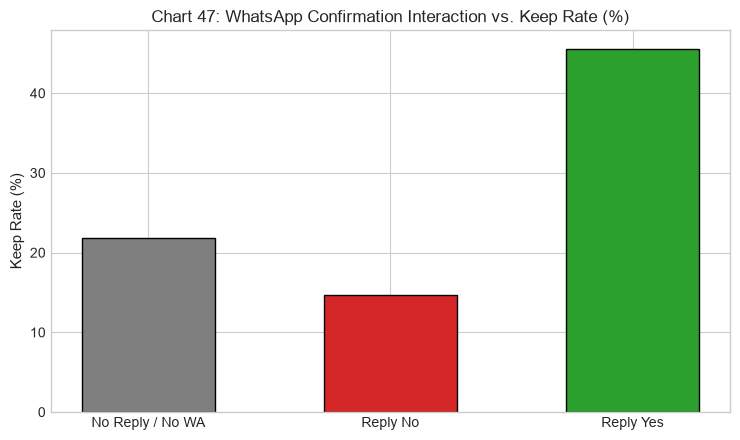

In [48]:
wa_yes = set(post_call[post_call['event_type'] == 'confirmation_reply_yes']['ptp_id'])
wa_no = set(post_call[post_call['event_type'] == 'confirmation_reply_no']['ptp_id'])
def get_wa(pid):
    if pid in wa_yes: return 'Reply Yes'
    if pid in wa_no: return 'Reply No'
    return 'No Reply / No WA'
ptps['wa_status'] = ptps['ptp_id'].apply(get_wa)
wa_perf = ptps.groupby('wa_status')['target_kept'].mean() * 100
plt.figure(figsize=(7.5, 4.5))
plt.bar(wa_perf.index, wa_perf.values, color=['#7f7f7f', '#d62728', '#2ca02c'], edgecolor='black', width=0.55)
plt.title("Chart 47: WhatsApp Confirmation Interaction vs. Keep Rate (%)")
plt.ylabel("Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 48: The 200 Diagnostic Annotations Typology Distribution


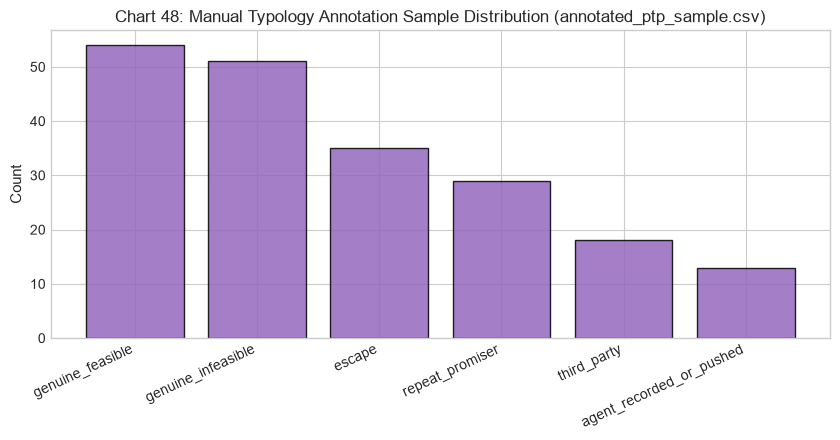

In [49]:
typ_counts = annotated['annotated_type'].value_counts()
plt.figure(figsize=(8.5, 4.5))
plt.bar(typ_counts.index, typ_counts.values, color='#9467bd', alpha=0.85, edgecolor='black')
plt.title("Chart 48: Manual Typology Annotation Sample Distribution (annotated_ptp_sample.csv)")
plt.xticks(rotation=25, ha='right')
plt.ylabel("Count")
plt.tight_layout()
plt.show()


### Chart 49: Diagnostic Typology Label Contamination vs. Actual Cash Paid


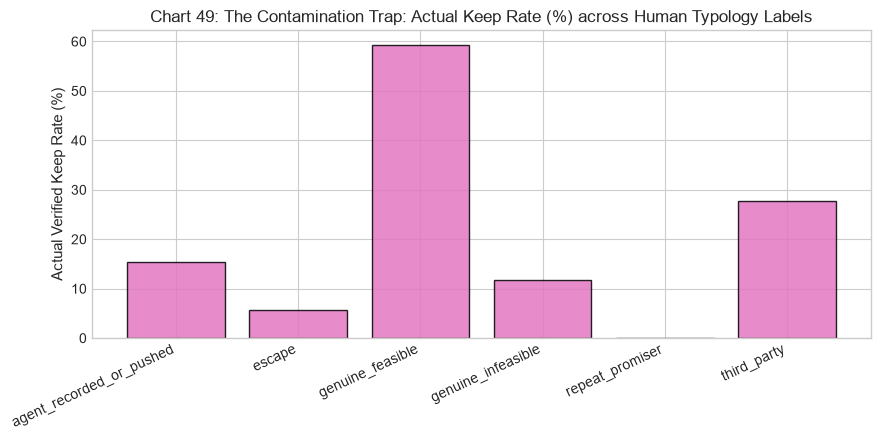

In [50]:
ann_ptp = annotated.merge(ptps[['ptp_id', 'target_kept', 'paid_in_window']], on='ptp_id')
ann_actual = ann_ptp.groupby('annotated_type')['target_kept'].mean() * 100
plt.figure(figsize=(9, 4.5))
plt.bar(ann_actual.index, ann_actual.values, color='#e377c2', alpha=0.85, edgecolor='black')
plt.title("Chart 49: The Contamination Trap: Actual Keep Rate (%) across Human Typology Labels")
plt.xticks(rotation=25, ha='right')
plt.ylabel("Actual Verified Keep Rate (%)")
plt.tight_layout()
plt.show()


### Chart 50: Official Grouped Split Consistency (Train vs Val vs Test)


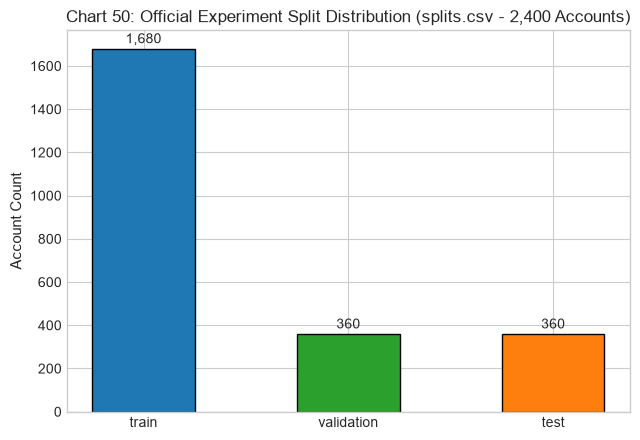

In [51]:
split_dist = splits['split'].value_counts()
plt.figure(figsize=(6.5, 4.5))
plt.bar(split_dist.index, split_dist.values, color=['#1f77b4', '#2ca02c', '#ff7f0e'], edgecolor='black', width=0.5)
plt.title("Chart 50: Official Experiment Split Distribution (splits.csv - 2,400 Accounts)")
plt.ylabel("Account Count")
for idx, v in enumerate(split_dist.values):
    plt.text(idx, v + 25, f"{v:,d}", ha='center')
plt.tight_layout()
plt.show()


## Summary of Visual Insights
- **Speech Timing is Paramount:** Pause duration latency (>600ms) and whether the customer explicitly states the amount are the top empirical differentiators of promise validity.
- **Rogue Agent interdiction:** Tele-agent `TA013`'s 24 fake PTPs are clearly separated from normal calling operations by zero-duration dropped calls.
- **Label Denoising:** Manual labels contain clear contamination (15 'genuine feasible' promises with ₹0 paid), confirming the necessity of deterministic payment verification.
